# Quantum Randomness → Procedural World

### Using real quantum measurement outcomes to seed a classical procedural world generator

This notebook builds a small 2D island world whose **high-level parameters** (shape, terrain roughness, sea level, forest density, village count/placement, biome thresholds) are derived from **quantum measurement outcomes**, while the actual terrain pixels are generated using a standard **layered/fractal noise** procedural algorithm.

## Concept

Quantum randomness is used the way a game designer uses a **world seed** — not to paint every pixel, but to decide *what kind of world* gets generated.

- ❌ **Not this:** assign a random quantum bit to every pixel (produces incoherent noise, no islands, no structure).
- ✅ **This:** use a modest number of quantum-measured bits to set a handful of **world parameters** (island shape, terrain scale, mountain intensity, water level, forest density, village count/placement, biome thresholds). A classical, deterministic procedural noise algorithm then uses those parameters to build a smooth, coherent heightmap and biome map.

**Key idea:**

> Quantum randomness decides *what kind of world* to generate.
> Classical procedural generation decides *how the world looks*, pixel by pixel.

## Quantum Randomness → World Parameters

We build a simple quantum circuit:

1. Put `N` qubits into an equal superposition using Hadamard gates (`H`).
2. Measure all qubits in the computational basis.
3. Repeat over many shots to build up a long stream of measurement bits.

Because each qubit is in `(|0⟩ + |1⟩)/√2`, each measured bit is (in an ideal simulator) an unbiased, independent binary outcome — a simulated quantum random bit source.

These bits are consumed sequentially from a bit-stream and converted into:

- **Integers** (e.g., village count, octave count)
- **Normalized floats mapped to ranges** (e.g., mountain intensity, water level, forest density)
- **Shuffle decisions** (the noise permutation table is built with a quantum-driven Fisher–Yates shuffle)
- **Coordinates** (village candidate positions are drawn directly from the bitstream)

`random.random()` / `numpy.random` are **never used** as an entropy source in this notebook — every stochastic decision traces back to the quantum bitstream.

## Procedural Generation Algorithm

1. **Quantum measurement** → long bitstream.
2. **Bitstream → parameters**: island falloff, terrain scale, octaves, persistence, lacunarity, mountain intensity, water level, forest density, village count, biome threshold offsets.
3. **Quantum-shuffled permutation table** → used by a deterministic value/Perlin-style noise function.
4. **Fractal (layered) noise** builds a smooth base heightmap from that permutation table.
5. **Island mask**: a radial falloff (quantum-derived exponent) pulls land toward the center and fades to ocean at the edges.
6. **Mountain shaping**: a quantum-derived exponent sharpens or flattens peaks.
7. **Thresholding**: continuous height values are cut into biomes (deep water, shallow water, beach, grass, forest, mountain, snow) using quantum-influenced thresholds.
8. **Structure placement**: villages are placed at quantum-derived coordinates, filtered by classical constraints (must be on land, minimum spacing, inside bounds).
9. **Visualization**: heightmap + final biome map rendered with matplotlib.

This mirrors how many game engines use one small seed to deterministically generate an entire coherent world.

In [5]:
# Install Qiskit and the Aer simulator (quiet install for Colab)
!pip install qiskit qiskit-aer pylatexenc --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.3 MB/s eta 0:00:00


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pylatexenc
import sys

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

print("Imports OK")

Imports OK


In [10]:
# ---- World / grid configuration ----
WORLD_SIZE = 128        # world grid is WORLD_SIZE x WORLD_SIZE cells

# ---- Quantum configuration ----
QUANTUM_QUBITS = 8       # qubits put into superposition per circuit execution
QUANTUM_SHOTS = 512      # number of circuit executions ("shots")
# total quantum bits available = QUANTUM_QUBITS * QUANTUM_SHOTS

# ---- Structure placement configuration ----
MIN_VILLAGE_DISTANCE = 10     # minimum allowed distance (grid cells) between villages
MAX_VILLAGE_ATTEMPTS = 800    # max candidate positions tried while placing villages

print(f"World grid: {WORLD_SIZE}x{WORLD_SIZE}")
print(f"Quantum bit budget: {QUANTUM_QUBITS * QUANTUM_SHOTS} bits "
      f"({QUANTUM_QUBITS} qubits x {QUANTUM_SHOTS} shots)")

World grid: 128x128
Quantum bit budget: 4096 bits (8 qubits x 512 shots)


In [12]:
def build_quantum_circuit(n_qubits):
    """
    Build a quantum circuit that puts every qubit into an equal superposition
    (|0> + |1>)/sqrt(2) via a Hadamard gate, then measures all qubits.

    Each execution ("shot") of this circuit yields n_qubits independent,
    unbiased random classical bits, sourced from quantum measurement collapse.
    """
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))                          # superposition
    qc.measure(range(n_qubits), range(n_qubits))   # measurement -> random bits
    return qc

quantum_circuit = build_quantum_circuit(QUANTUM_QUBITS)
quantum_circuit.draw("text")

┌───┐┌─┐                     
q_0: ┤ H ├┤M├─────────────────────
     ├───┤└╥┘┌─┐                  
q_1: ┤ H ├─╫─┤M├──────────────────
     ├───┤ ║ └╥┘┌─┐               
q_2: ┤ H ├─╫──╫─┤M├───────────────
     ├───┤ ║  ║ └╥┘┌─┐            
q_3: ┤ H ├─╫──╫──╫─┤M├────────────
     ├───┤ ║  ║  ║ └╥┘┌─┐         
q_4: ┤ H ├─╫──╫──╫──╫─┤M├─────────
     ├───┤ ║  ║  ║  ║ └╥┘┌─┐      
q_5: ┤ H ├─╫──╫──╫──╫──╫─┤M├──────
     ├───┤ ║  ║  ║  ║  ║ └╥┘┌─┐   
q_6: ┤ H ├─╫──╫──╫──╫──╫──╫─┤M├───
     ├───┤ ║  ║  ║  ║  ║  ║ └╥┘┌─┐
q_7: ┤ H ├─╫──╫──╫──╫──╫──╫──╫─┤M├
     └───┘ ║  ║  ║  ║  ║  ║  ║ └╥┘
c: 8/══════╩══╩══╩══╩══╩══╩══╩══╩═
           0  1  2  3  4  5  6  7

In [13]:
# Run the circuit on Qiskit's Aer simulator.
# memory=True lets us retrieve the individual bitstring from every single shot
# (rather than only aggregated counts), giving us a long, non-repeating stream.
simulator = AerSimulator()
job = simulator.run(quantum_circuit, shots=QUANTUM_SHOTS, memory=True)
result = job.result()
shot_memory = result.get_memory()  # list of per-shot bitstrings, e.g. ['01101011', ...]

# Concatenate every shot's bits into one long quantum-measured bitstream
quantum_bitstream_str = ''.join(shot_memory)
quantum_bits = [int(b) for b in quantum_bitstream_str]

print(f"Shots executed: {QUANTUM_SHOTS}")
print(f"Total quantum bits collected: {len(quantum_bits)}")
print(f"First 64 bits: {quantum_bitstream_str[:64]}...")

Shots executed: 512
Total quantum bits collected: 4096
First 64 bits: 0110010011001001010111010111010110110100011111111011100111111111...


In [14]:
class QuantumBitStream:
    """
    A cursor-based reader over a fixed pool of quantum-measured bits.
    Every call consumes the *next* N bits from the same underlying quantum
    measurement pool, so every parameter/decision derived from it traces
    back to actual quantum measurement outcomes.
    """
    def __init__(self, bits):
        self.bits = bits
        self.cursor = 0

    def next_bits(self, n):
        if self.cursor + n > len(self.bits):
            # Wrap around rather than crash if the pool is exhausted.
            # (Deterministic reuse -- fine for procedural generation, not for crypto.)
            self.cursor = 0
        chunk = self.bits[self.cursor:self.cursor + n]
        self.cursor += n
        return chunk

    def next_int(self, n_bits):
        chunk = self.next_bits(n_bits)
        value = 0
        for b in chunk:
            value = (value << 1) | b
        return value

    def next_float(self, n_bits=16):
        max_val = (1 << n_bits) - 1
        return self.next_int(n_bits) / max_val

    def next_range(self, low, high, n_bits=16):
        return low + self.next_float(n_bits) * (high - low)

    def next_int_range(self, low, high, n_bits=8):
        span = high - low
        return low + (self.next_int(n_bits) % span)


def quantum_shuffle(arr, bitstream):
    """Fisher-Yates shuffle driven entirely by quantum-measured bits."""
    arr = list(arr)
    for i in range(len(arr) - 1, 0, -1):
        bits_needed = max(1, i.bit_length())
        j = bitstream.next_int(bits_needed) % (i + 1)
        arr[i], arr[j] = arr[j], arr[i]
    return arr


def derive_world_parameters(bitstream):
    """Convert quantum bits into human-meaningful world-generation parameters."""
    params = {}
    params['island_falloff']            = bitstream.next_range(1.2, 3.5, 12)
    params['terrain_scale']             = bitstream.next_range(20, 60, 12)
    params['mountain_intensity']        = bitstream.next_range(0.6, 2.2, 12)
    params['water_level']               = bitstream.next_range(0.30, 0.50, 12)
    params['forest_density']            = bitstream.next_range(0.25, 0.75, 12)
    params['village_count']             = int(bitstream.next_int_range(3, 9, 8))
    params['snow_threshold_offset']     = bitstream.next_range(-0.05, 0.05, 10)
    params['mountain_threshold_offset'] = bitstream.next_range(-0.05, 0.05, 10)
    params['octaves']                   = int(bitstream.next_int_range(3, 7, 4))
    params['persistence']               = bitstream.next_range(0.35, 0.65, 10)
    params['lacunarity']                = bitstream.next_range(1.8, 2.4, 10)
    return params

qstream = QuantumBitStream(quantum_bits)
world_params = derive_world_parameters(qstream)

print(f"Derived {len(world_params)} world parameters from {len(quantum_bits)} quantum bits.")

Derived 11 world parameters from 4096 quantum bits.


In [15]:
# ---- Deterministic value/Perlin-style noise (classical procedural algorithm) ----

GRAD_X = np.array([1, -1, 1, -1, 1, -1, 0, 0])
GRAD_Y = np.array([1, 1, -1, -1, 0, 0, 1, -1])

def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def grad_vec(h, x, y):
    h = h & 7
    return GRAD_X[h] * x + GRAD_Y[h] * y

def perlin_vectorized(X, Y, perm):
    """Vectorized value/Perlin-style noise over arrays X, Y using permutation table `perm`."""
    xi = np.floor(X).astype(int) & 255
    yi = np.floor(Y).astype(int) & 255
    xf = X - np.floor(X)
    yf = Y - np.floor(Y)
    u = fade(xf)
    v = fade(yf)

    aa = perm[perm[xi] + yi]
    ab = perm[perm[xi] + yi + 1]
    ba = perm[perm[xi + 1] + yi]
    bb = perm[perm[xi + 1] + yi + 1]

    x1 = lerp(grad_vec(aa, xf, yf),     grad_vec(ba, xf - 1, yf),     u)
    x2 = lerp(grad_vec(ab, xf, yf - 1), grad_vec(bb, xf - 1, yf - 1), u)
    return lerp(x1, x2, v)

def fractal_noise(shape, perm, scale, octaves, persistence, lacunarity):
    """Layered (fractal Brownian motion) noise built from repeated octaves of base noise."""
    ys, xs = np.indices(shape)
    height = np.zeros(shape, dtype=float)
    amplitude, frequency, max_amp = 1.0, 1.0, 0.0
    for _ in range(octaves):
        nx = xs / scale * frequency
        ny = ys / scale * frequency
        height += amplitude * perlin_vectorized(nx, ny, perm)
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return height / max_amp

def build_permutation_table(bitstream):
    """Build the noise permutation table using a quantum-driven shuffle (not numpy/random)."""
    base = list(range(256))
    shuffled = quantum_shuffle(base, bitstream)
    return np.array(shuffled + shuffled)  # doubled to avoid index overflow

def apply_island_mask(height, falloff, shape):
    """Radial falloff mask that pulls land toward the center (quantum-derived exponent)."""
    ys, xs = np.indices(shape)
    cx, cy = shape[1] / 2, shape[0] / 2
    dx = (xs - cx) / (shape[1] / 2)
    dy = (ys - cy) / (shape[0] / 2)
    dist = np.sqrt(dx ** 2 + dy ** 2)
    mask = np.clip(1 - dist ** falloff, 0, 1)
    return height * mask

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)


# ---- Build the world's heightmap using quantum-derived parameters ----

PERM = build_permutation_table(qstream)

raw_height = fractal_noise(
    (WORLD_SIZE, WORLD_SIZE), PERM,
    scale=world_params['terrain_scale'],
    octaves=world_params['octaves'],
    persistence=world_params['persistence'],
    lacunarity=world_params['lacunarity']
)
raw_height = normalize(raw_height)

island_height = apply_island_mask(raw_height, world_params['island_falloff'], (WORLD_SIZE, WORLD_SIZE))
island_height = normalize(island_height)

heightmap = normalize(island_height ** world_params['mountain_intensity'])

print("Heightmap generated.")
print("Shape:", heightmap.shape, " Range:", round(heightmap.min(), 3), "-", round(heightmap.max(), 3))

Heightmap generated.
Shape: (128, 128)  Range: 0.0 - 1.0


In [16]:
def classify_biomes(height, params, perm):
    """
    Convert continuous height values into discrete biome codes using
    quantum-influenced thresholds:
      0 = deep water, 1 = shallow water, 2 = beach,
      3 = grass, 4 = forest, 5 = mountain, 6 = snow
    """
    water_level = params['water_level']
    deep_water_t   = max(0.0, water_level - 0.12)
    shallow_water_t = water_level
    beach_t        = water_level + 0.035
    mountain_t     = min(0.95, 0.68 + params['mountain_threshold_offset'])
    snow_t         = min(0.98, 0.85 + params['snow_threshold_offset'])

    biome = np.zeros(height.shape, dtype=int)
    biome[height <= deep_water_t] = 0
    biome[(height > deep_water_t) & (height <= shallow_water_t)] = 1
    biome[(height > shallow_water_t) & (height <= beach_t)] = 2

    grass_mask = (height > beach_t) & (height <= mountain_t)
    biome[grass_mask] = 3
    biome[(height > mountain_t) & (height <= snow_t)] = 5
    biome[height > snow_t] = 6

    # Secondary noise layer scatters forest within grass; density is quantum-derived.
    ys, xs = np.indices(height.shape)
    forest_scale = max(4.0, params['terrain_scale'] * 0.4)
    forest_noise = normalize(perlin_vectorized(xs / forest_scale, ys / forest_scale, perm))
    forest_mask = grass_mask & (forest_noise > (1 - params['forest_density']))
    biome[forest_mask] = 4

    thresholds = {
        'deep_water_t': deep_water_t,
        'shallow_water_t': shallow_water_t,
        'beach_t': beach_t,
        'mountain_t': mountain_t,
        'snow_t': snow_t,
    }
    return biome, thresholds

biome, thresholds = classify_biomes(heightmap, world_params, PERM)
print("Biome codes: 0=deep water, 1=shallow water, 2=beach, 3=grass, 4=forest, 5=mountain, 6=snow")
print("Thresholds:", {k: round(v, 3) for k, v in thresholds.items()})

Biome codes: 0=deep water, 1=shallow water, 2=beach, 3=grass, 4=forest, 5=mountain, 6=snow
Thresholds: {'deep_water_t': 0.236, 'shallow_water_t': 0.356, 'beach_t': 0.391, 'mountain_t': 0.68, 'snow_t': 0.865}


In [17]:
def place_villages(biome, params, bitstream,
                    min_distance=MIN_VILLAGE_DISTANCE,
                    max_attempts=MAX_VILLAGE_ATTEMPTS):
    """
    Place villages using quantum-derived coordinates, subject to classical constraints:
      - must land on grass (3) or forest (4) biome
      - must be inside the grid (guaranteed by construction via modulo)
      - must not be within `min_distance` of another village
    """
    h, w = biome.shape
    coord_bits = max(8, w.bit_length(), h.bit_length())
    villages = []
    attempts = 0
    target = params['village_count']

    while len(villages) < target and attempts < max_attempts:
        attempts += 1
        x = bitstream.next_int(coord_bits) % w
        y = bitstream.next_int(coord_bits) % h

        if biome[y, x] not in (3, 4):  # must be on land (grass/forest)
            continue

        far_enough = all(
            (x - vx) ** 2 + (y - vy) ** 2 >= min_distance ** 2
            for vx, vy in villages
        )
        if far_enough:
            villages.append((x, y))

    return villages, attempts

villages, village_attempts = place_villages(biome, world_params, qstream)
print(f"Placed {len(villages)}/{world_params['village_count']} villages in {village_attempts} attempts.")

Placed 8/8 villages in 80 attempts.


In [18]:
def validate_world(biome, villages, min_distance=MIN_VILLAGE_DISTANCE):
    """Check that all placement constraints are actually satisfied."""
    issues = []
    h, w = biome.shape

    for (x, y) in villages:
        if not (0 <= x < w and 0 <= y < h):
            issues.append(f"Village at ({x},{y}) is outside world bounds")
        elif biome[y, x] not in (3, 4):
            issues.append(f"Village at ({x},{y}) is not on land (biome={biome[y, x]})")

    for i in range(len(villages)):
        for j in range(i + 1, len(villages)):
            dx = villages[i][0] - villages[j][0]
            dy = villages[i][1] - villages[j][1]
            if dx * dx + dy * dy < min_distance ** 2:
                issues.append(f"Villages {i} and {j} are too close / overlapping")

    if issues:
        print("Constraint issues found:")
        for issue in issues:
            print(" -", issue)
    else:
        print(f"All constraints satisfied: {len(villages)} villages validly placed on land, "
              f"in-bounds, and non-overlapping.")
    return issues

validation_issues = validate_world(biome, villages)

All constraints satisfied: 8 villages validly placed on land, in-bounds, and non-overlapping.


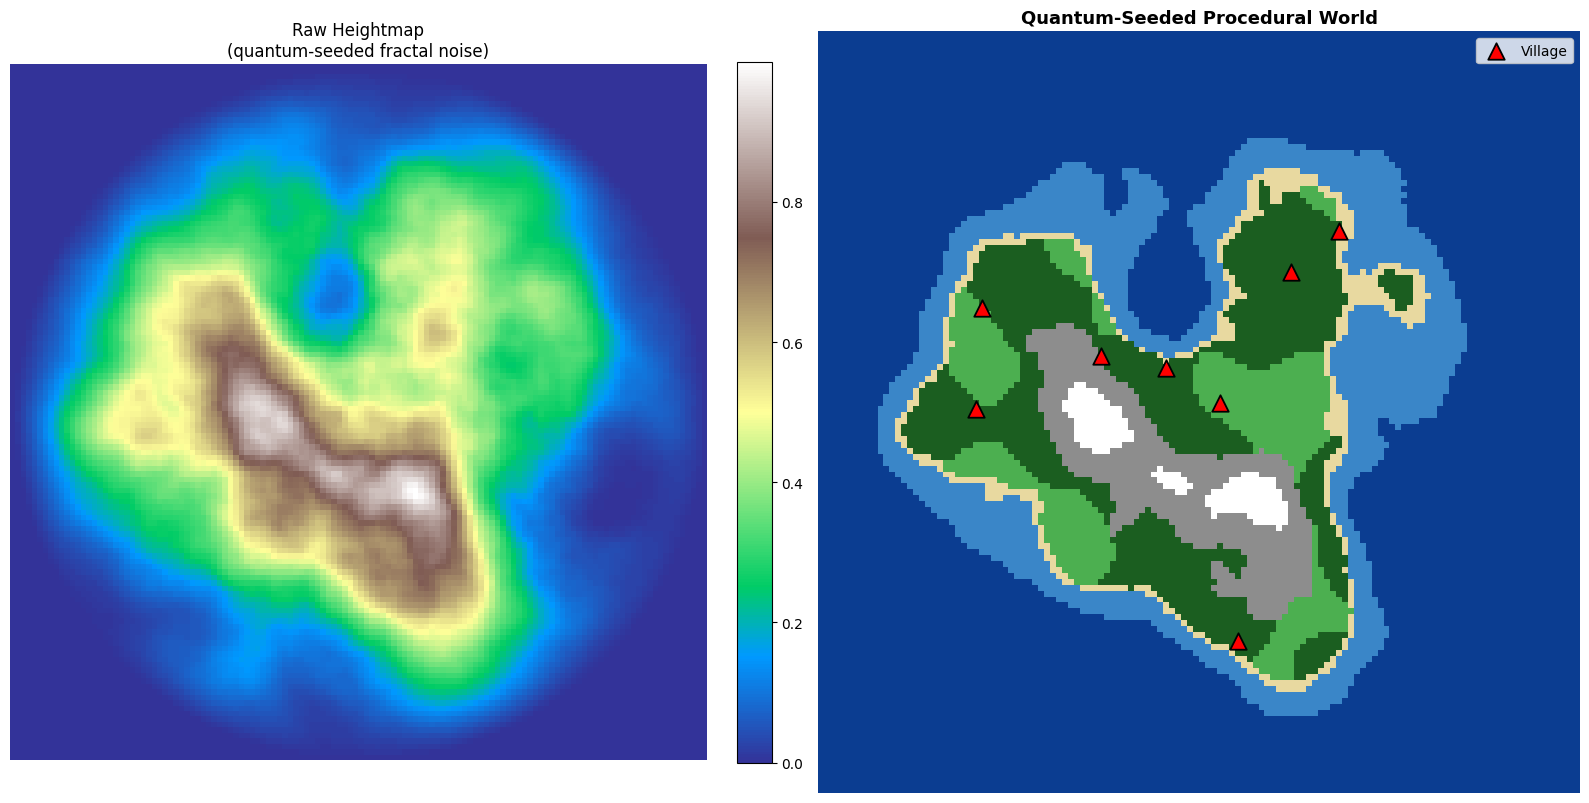

In [19]:
# Color palette for each biome code
BIOME_COLORS = {
    0: '#0b3d91',  # deep water
    1: '#3a86c8',  # shallow water
    2: '#e8d9a0',  # beach
    3: '#4caf50',  # grass
    4: '#1b5e20',  # forest
    5: '#8d8d8d',  # mountain
    6: '#ffffff',  # snow
}

def biome_to_rgb(biome):
    rgb = np.zeros((*biome.shape, 3))
    for code, hex_color in BIOME_COLORS.items():
        rgb[biome == code] = mcolors.to_rgb(hex_color)
    return rgb

def visualize_world(height, biome, villages, params, title="Quantum-Seeded Procedural World"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    im0 = axes[0].imshow(height, cmap='terrain', origin='upper')
    axes[0].set_title("Raw Heightmap\n(quantum-seeded fractal noise)", fontsize=12)
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    rgb = biome_to_rgb(biome)
    axes[1].imshow(rgb, origin='upper')
    if villages:
        vx = [v[0] for v in villages]
        vy = [v[1] for v in villages]
        axes[1].scatter(vx, vy, c='red', marker='^', s=140,
                         edgecolor='black', linewidth=1.3, label='Village', zorder=5)
        axes[1].legend(loc='upper right')
    axes[1].set_title(title, fontsize=13, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_world(heightmap, biome, villages, world_params)

In [20]:
print("=" * 60)
print(" QUANTUM-DERIVED WORLD PARAMETERS")
print("=" * 60)

labels = {
    'island_falloff': 'Island falloff (shape sharpness)',
    'terrain_scale': 'Terrain noise scale (feature size)',
    'mountain_intensity': 'Mountain intensity (peak sharpness)',
    'water_level': 'Water level',
    'forest_density': 'Forest density',
    'village_count': 'Requested village count',
    'snow_threshold_offset': 'Snow threshold offset',
    'mountain_threshold_offset': 'Mountain threshold offset',
    'octaves': 'Noise octaves',
    'persistence': 'Noise persistence',
    'lacunarity': 'Noise lacunarity',
}

for key, label in labels.items():
    value = world_params[key]
    if isinstance(value, float):
        print(f"  {label:<38s}: {value:.4f}")
    else:
        print(f"  {label:<38s}: {value}")

print("-" * 60)
print(" DERIVED BIOME THRESHOLDS")
print("-" * 60)
for key, value in thresholds.items():
    print(f"  {key:<38s}: {value:.4f}")

print("-" * 60)
print(" STRUCTURES")
print("-" * 60)
print(f"  {'Villages placed':<38s}: {len(villages)} / {world_params['village_count']}")
print(f"  {'Placement attempts used':<38s}: {village_attempts}")
print(f"  {'Quantum bits consumed (cursor pos)':<38s}: {qstream.cursor} (pool size {len(qstream.bits)})")
print("=" * 60)

 QUANTUM-DERIVED WORLD PARAMETERS
  Island falloff (shape sharpness)      : 2.1054
  Terrain noise scale (feature size)    : 43.4139
  Mountain intensity (peak sharpness)   : 1.3357
  Water level                           : 0.3562
  Forest density                        : 0.6132
  Requested village count               : 8
  Snow threshold offset                 : 0.0150
  Mountain threshold offset             : 0.0002
  Noise octaves                         : 6
  Noise persistence                     : 0.4462
  Noise lacunarity                      : 1.8792
------------------------------------------------------------
 DERIVED BIOME THRESHOLDS
------------------------------------------------------------
  deep_water_t                          : 0.2362
  shallow_water_t                       : 0.3562
  beach_t                               : 0.3912
  mountain_t                            : 0.6802
  snow_t                                : 0.8650
-------------------------------------------

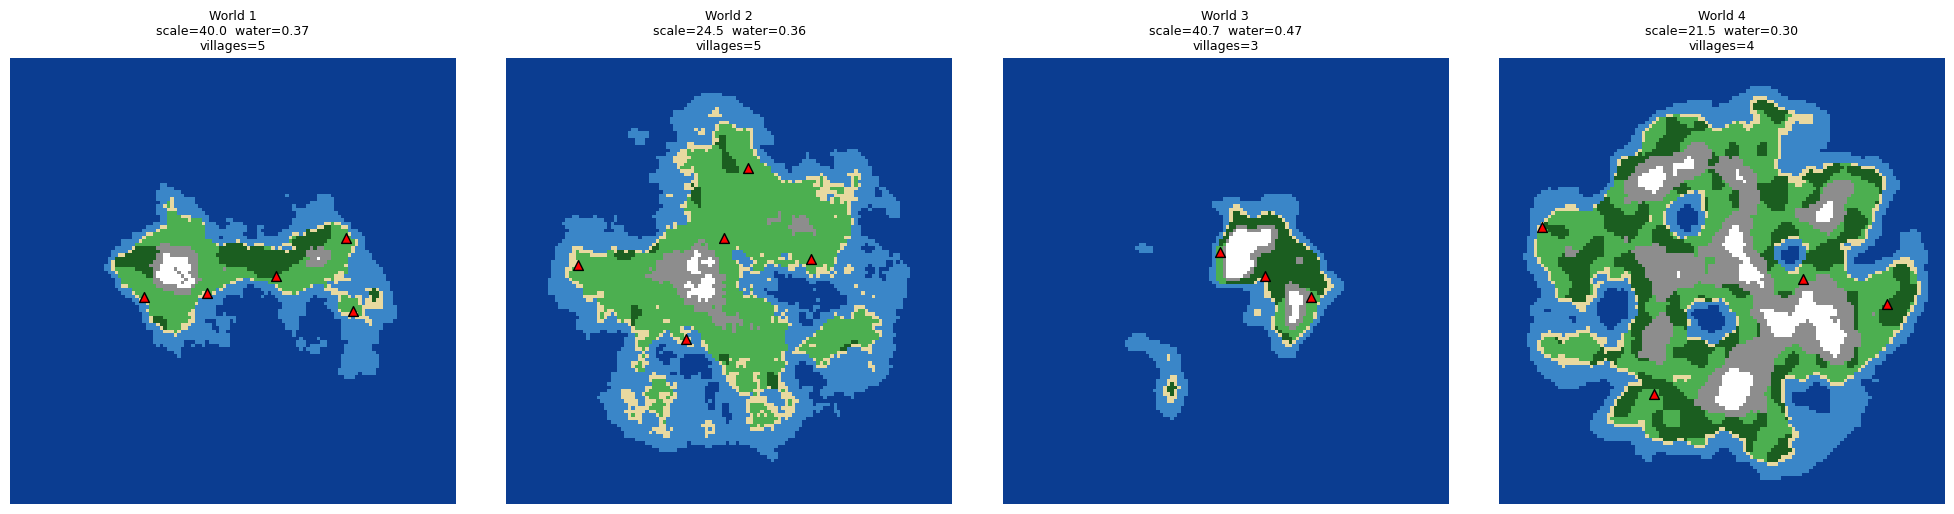

In [21]:
def generate_full_world(world_size=WORLD_SIZE, n_qubits=QUANTUM_QUBITS, shots=QUANTUM_SHOTS):
    """Run the entire quantum -> procedural pipeline end-to-end and return the result."""
    # 1. Fresh quantum measurement
    qc = build_quantum_circuit(n_qubits)
    sim = AerSimulator()
    mem = sim.run(qc, shots=shots, memory=True).result().get_memory()
    bits = [int(b) for b in ''.join(mem)]
    stream = QuantumBitStream(bits)

    # 2. Bits -> parameters
    params = derive_world_parameters(stream)

    # 3. Bits -> noise permutation table
    perm = build_permutation_table(stream)

    # 4. Procedural heightmap
    raw = normalize(fractal_noise((world_size, world_size), perm,
                                   params['terrain_scale'], params['octaves'],
                                   params['persistence'], params['lacunarity']))
    island = normalize(apply_island_mask(raw, params['island_falloff'], (world_size, world_size)))
    height = normalize(island ** params['mountain_intensity'])

    # 5. Biomes
    biome_local, thresholds_local = classify_biomes(height, params, perm)

    # 6. Structures
    villages_local, attempts_local = place_villages(biome_local, params, stream)

    return {
        'height': height, 'biome': biome_local, 'villages': villages_local,
        'params': params, 'thresholds': thresholds_local
    }


NUM_WORLDS = 4
fig, axes = plt.subplots(1, NUM_WORLDS, figsize=(5 * NUM_WORLDS, 5))

for i in range(NUM_WORLDS):
    world = generate_full_world()
    rgb = biome_to_rgb(world['biome'])
    axes[i].imshow(rgb, origin='upper')
    if world['villages']:
        vx = [v[0] for v in world['villages']]
        vy = [v[1] for v in world['villages']]
        axes[i].scatter(vx, vy, c='red', marker='^', s=50, edgecolor='black', linewidth=1.0)
    p = world['params']
    axes[i].set_title(
        f"World {i+1}\nscale={p['terrain_scale']:.1f}  water={p['water_level']:.2f}\n"
        f"villages={len(world['villages'])}",
        fontsize=9
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Explanation

- The **quantum circuit** only ever produces raw random bits — it has no notion of "islands", "mountains", or "villages".
- All spatial structure in the final map comes from the **classical fractal noise algorithm**, the **radial island mask**, and the **thresholding/masking logic** — standard, well-understood procedural generation techniques.
- The quantum contribution is limited to choosing *which* world (out of a large space of possible parameter combinations) gets generated — analogous to a random seed, but sourced from quantum superposition and measurement instead of a classical pseudo-random number generator.
- Because parameters vary continuously and are applied consistently across the *entire* grid (not per-pixel), the resulting worlds stay smooth and visually coherent no matter what the quantum bits happen to be.
- Even the noise function's internal permutation table is built with a quantum-driven Fisher–Yates shuffle, so the "shape" of the base noise itself traces back to quantum measurement outcomes.

## Extensions

- Run the quantum circuit on real quantum hardware via IBM Quantum to source genuine hardware-measured randomness.
- Add more biome types (desert, tundra, swamp) with additional quantum-derived thresholds.
- Extend to 3D by using the heightmap directly as terrain elevation (export to a mesh / voxel engine).
- Use quantum expectation values from parameterized circuits (rather than raw bits) to drive continuous parameters directly.
- Add rivers by tracing descent paths from mountain peaks to the sea.
- Add road networks connecting villages using pathfinding across the walkable biome mask.
- Use entangled qubit measurements to derive *correlated* parameters (e.g., linking mountain intensity and snow threshold) and compare resulting worlds to the independent-bit version.

## Bonus: Extended Biomes (Desert, Tundra, Swamp)

To add more biome variety **without** breaking coherence, we introduce two new
quantum-seeded noise layers, following a classic Whittaker-diagram approach:

- **Moisture map** — a second fractal noise layer, built from an independently
  quantum-shuffled permutation table.
- **Temperature map** — a latitude-style gradient (warm near a quantum-shifted
  "equator row", cold near the poles).

Biome is now decided by **height + moisture + temperature together**, all of
which are classical, deterministic, continuous fields. Quantum measurement
only sets the *thresholds* and the *equator position/noise scale* — never
individual pixels — so biomes remain smooth and geographically sensible
(deserts are warm+dry, swamps are low+wet, tundra is cold+dry).

In [22]:
def derive_extended_parameters(bitstream):
    """Extra quantum-derived parameters for extended biomes, rivers, and roads."""
    ext = {}
    # --- biome-shaping parameters ---
    ext['moisture_scale']      = bitstream.next_range(20, 50, 12)
    ext['equator_shift']       = bitstream.next_range(-0.3, 0.3, 12)
    ext['desert_moisture_t']   = bitstream.next_range(0.25, 0.40, 10)
    ext['desert_temp_t']       = bitstream.next_range(0.55, 0.70, 10)
    ext['swamp_moisture_t']    = bitstream.next_range(0.60, 0.75, 10)
    ext['swamp_height_t']      = bitstream.next_range(0.45, 0.55, 10)
    ext['tundra_temp_t']       = bitstream.next_range(0.25, 0.40, 10)
    ext['tundra_moisture_t']   = bitstream.next_range(0.30, 0.45, 10)
    ext['forest_moisture_t']   = bitstream.next_range(0.45, 0.60, 10)
    # --- river parameters ---
    ext['river_count']         = int(bitstream.next_int_range(2, 6, 4))
    return ext

extended_params = derive_extended_parameters(qstream)
world_params.update(extended_params)

print("Extended quantum-derived parameters:")
for k, v in extended_params.items():
    print(f"  {k:<20s}: {v if isinstance(v, int) else round(v, 4)}")

Extended quantum-derived parameters:
  moisture_scale      : 24.6227
  equator_shift       : -0.0219
  desert_moisture_t   : 0.2828
  desert_temp_t       : 0.5927
  swamp_moisture_t    : 0.6997
  swamp_height_t      : 0.5387
  tundra_temp_t       : 0.3235
  tundra_moisture_t   : 0.376
  forest_moisture_t   : 0.4969
  river_count         : 3


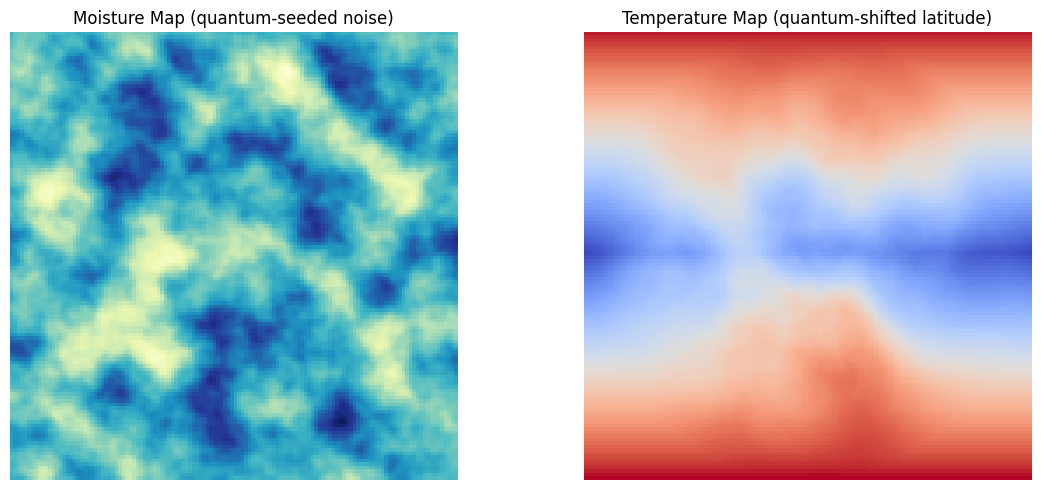

In [23]:
# ---- Moisture map: a second, independently quantum-shuffled noise field ----
PERM_MOISTURE = build_permutation_table(qstream)  # fresh quantum-driven shuffle

moisture_raw = fractal_noise(
    (WORLD_SIZE, WORLD_SIZE), PERM_MOISTURE,
    scale=world_params['moisture_scale'],
    octaves=4, persistence=0.5, lacunarity=2.0
)
moisture_map = normalize(moisture_raw)

# ---- Temperature map: latitude gradient with a quantum-shifted "equator" ----
def generate_temperature_map(shape, params, height):
    h, w = shape
    ys, _ = np.indices(shape)
    equator_row = h / 2 + params['equator_shift'] * (h / 2)
    lat_dist = np.abs(ys - equator_row) / (h / 2)
    temp = 1 - np.clip(lat_dist, 0, 1)          # warm at equator, cold at poles
    temp = temp - height * 0.4                  # higher elevation -> cooler
    return normalize(temp)

temperature_map = generate_temperature_map((WORLD_SIZE, WORLD_SIZE), world_params, heightmap)

# Quick preview of the two new fields
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(moisture_map, cmap='YlGnBu')
axes[0].set_title("Moisture Map (quantum-seeded noise)")
axes[0].axis('off')
axes[1].imshow(temperature_map, cmap='coolwarm_r')
axes[1].set_title("Temperature Map (quantum-shifted latitude)")
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [24]:
def classify_biomes_extended(height, moisture, temperature, params):
    """
    Biome codes:
      0 deep water, 1 shallow water, 2 beach, 3 grass, 4 forest,
      5 mountain, 6 snow, 7 desert, 8 tundra, 9 swamp
    """
    water_level      = params['water_level']
    deep_water_t     = max(0.0, water_level - 0.12)
    shallow_water_t  = water_level
    beach_t          = water_level + 0.035
    mountain_t       = min(0.95, 0.68 + params['mountain_threshold_offset'])
    snow_t           = min(0.98, 0.85 + params['snow_threshold_offset'])

    biome = np.zeros(height.shape, dtype=int)
    biome[height <= deep_water_t] = 0
    biome[(height > deep_water_t) & (height <= shallow_water_t)] = 1
    biome[(height > shallow_water_t) & (height <= beach_t)] = 2

    land_mask = height > beach_t
    high_mask = height > mountain_t
    snow_mask = height > snow_t

    biome[high_mask] = 5   # mountain
    biome[snow_mask] = 6   # snow overrides mountain at the very top

    low_land = land_mask & ~high_mask  # normal-elevation land -> climate-driven biome

    desert_mask = low_land & (temperature > params['desert_temp_t']) & \
                              (moisture < params['desert_moisture_t'])
    swamp_mask  = low_land & (height < params['swamp_height_t']) & \
                              (moisture > params['swamp_moisture_t']) & ~desert_mask
    tundra_mask = low_land & (temperature < params['tundra_temp_t']) & \
                              (moisture < params['tundra_moisture_t']) & \
                              ~desert_mask & ~swamp_mask
    forest_mask = low_land & (moisture > params['forest_moisture_t']) & \
                              ~desert_mask & ~swamp_mask & ~tundra_mask
    grass_mask  = low_land & ~desert_mask & ~swamp_mask & ~tundra_mask & ~forest_mask

    biome[desert_mask] = 7
    biome[swamp_mask]  = 9
    biome[tundra_mask] = 8
    biome[forest_mask] = 4
    biome[grass_mask]  = 3

    thresholds = {
        'deep_water_t': deep_water_t, 'shallow_water_t': shallow_water_t,
        'beach_t': beach_t, 'mountain_t': mountain_t, 'snow_t': snow_t
    }
    return biome, thresholds

# Replace the simple biome map with the extended one for the rest of the notebook
biome_ext, thresholds_ext = classify_biomes_extended(heightmap, moisture_map, temperature_map, world_params)

# Extend the color palette with the new biome types
BIOME_COLORS.update({
    7: '#d9b45f',  # desert
    8: '#a9c4b8',  # tundra
    9: '#4b6455',  # swamp
})

print("Extended biome map generated with 10 biome codes.")
print("New biome counts:", {c: int((biome_ext == c).sum()) for c in range(10)})

Extended biome map generated with 10 biome codes.
New biome counts: {0: 10296, 1: 2031, 2: 470, 3: 1005, 4: 1162, 5: 752, 6: 193, 7: 131, 8: 46, 9: 298}


All constraints satisfied: 8 villages validly placed on land, in-bounds, and non-overlapping.
Placed 8/8 villages on the extended biome map.


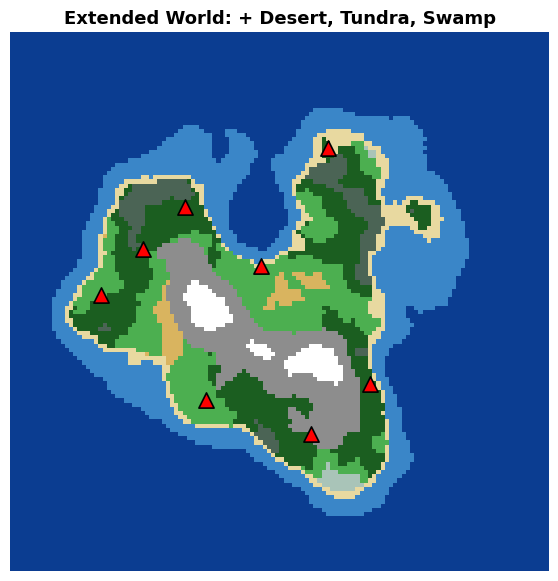

In [25]:
# Grass/forest cells shift under the extended classification, so we
# re-validate/re-place villages against the new biome_ext map.
villages_ext, village_attempts_ext = place_villages(biome_ext, world_params, qstream)
validation_issues_ext = validate_world(biome_ext, villages_ext)

print(f"Placed {len(villages_ext)}/{world_params['village_count']} villages on the extended biome map.")

# Quick look at the richer biome map
rgb_ext = biome_to_rgb(biome_ext)
plt.figure(figsize=(7, 7))
plt.imshow(rgb_ext, origin='upper')
if villages_ext:
    vx = [v[0] for v in villages_ext]
    vy = [v[1] for v in villages_ext]
    plt.scatter(vx, vy, c='red', marker='^', s=120, edgecolor='black', linewidth=1.2)
plt.title("Extended World: + Desert, Tundra, Swamp", fontsize=13, fontweight='bold')
plt.axis('off')
plt.show()

## Bonus: Rivers

Rivers are generated with a classical **steepest-descent walk**:

1. Pick a handful of high-elevation "source" points (quantum-chosen from the
   highest terrain cells, spaced apart).
2. From each source, repeatedly step to the lowest neighboring cell
   (8-connected) until sea level is reached, or the path gets stuck in a pit.

This is a standard technique in procedural terrain generation (hydraulic
erosion / flow-path tracing) — it is entirely deterministic classical logic;
quantum randomness only decides **where the river sources start**.

In [26]:
RIVER_SOURCE_PERCENTILE = 92   # rivers start from roughly the top 8% of elevations
RIVER_MIN_SPACING = 15         # minimum distance between river sources
RIVER_MAX_STEPS = 300          # safety cap on river length

def place_river_sources(height, params, bitstream,
                         percentile=RIVER_SOURCE_PERCENTILE,
                         min_spacing=RIVER_MIN_SPACING,
                         max_attempts=500):
    """Quantum-chosen river source points, drawn from high-elevation cells."""
    threshold = np.percentile(height, percentile)
    candidates = np.argwhere(height >= threshold)  # (y, x) pairs
    sources = []
    attempts = 0
    n_sources = params['river_count']

    while len(sources) < n_sources and attempts < max_attempts and len(candidates) > 0:
        attempts += 1
        idx = bitstream.next_int(16) % len(candidates)
        y, x = candidates[idx]
        if all((x - sx) ** 2 + (y - sy) ** 2 >= min_spacing ** 2 for sx, sy in sources):
            sources.append((int(x), int(y)))
    return sources


def trace_river(height, start, water_level, max_steps=RIVER_MAX_STEPS):
    """Classical steepest-descent walk from a mountain peak down to the sea."""
    h, w = height.shape
    path = [start]
    visited = {start}
    x, y = start

    for _ in range(max_steps):
        if height[y, x] <= water_level:
            break
        best = None
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                if dx == 0 and dy == 0:
                    continue
                nx, ny = x + dx, y + dy
                if 0 <= nx < w and 0 <= ny < h and (nx, ny) not in visited:
                    if best is None or height[ny, nx] < best[2]:
                        best = (nx, ny, height[ny, nx])
        if best is None or best[2] > height[y, x] + 1e-6:
            break  # no downhill neighbor available -> stuck in a local pit
        x, y = best[0], best[1]
        path.append((x, y))
        visited.add((x, y))

    return path


river_sources = place_river_sources(heightmap, world_params, qstream)
rivers = [trace_river(heightmap, src, world_params['water_level']) for src in river_sources]
rivers = [r for r in rivers if len(r) > 3]  # discard trivially short rivers

print(f"Generated {len(rivers)} river(s) from {len(river_sources)} quantum-chosen source(s).")

Generated 3 river(s) from 3 quantum-chosen source(s).


## Bonus: Road Networks

Roads connect villages using classical pathfinding (A\*) over a **walkable
cost grid** derived from the biome map:

- Grass / forest / desert / tundra / beach → low cost (easy to traverse)
- Swamp → higher cost (slow going)
- Mountain / snow → very high cost (avoided unless unavoidable)
- Water → impassable (infinite cost)

To avoid an expensive all-pairs shortest-path search, villages are first
connected with a **minimum spanning tree** (using straight-line distance),
and only the resulting MST edges are actually pathfound with A\* across the
cost grid. Quantum randomness has no role here — this stage is purely
classical constraint-based generation on top of the (quantum-seeded) map.

In [27]:
import heapq

def build_cost_grid(biome):
    """Movement cost per biome type. Water is impassable (inf)."""
    cost = np.full(biome.shape, np.inf)
    cost[biome == 3] = 1.0   # grass
    cost[biome == 4] = 1.2   # forest
    cost[biome == 2] = 1.5   # beach
    cost[biome == 7] = 1.3   # desert
    cost[biome == 8] = 1.6   # tundra
    cost[biome == 9] = 3.0   # swamp
    cost[biome == 5] = 6.0   # mountain
    cost[biome == 6] = 8.0   # snow
    return cost


def astar(cost_grid, start, goal):
    """Standard A* search over the cost grid. Points are (x, y) tuples."""
    h, w = cost_grid.shape

    def heuristic(a, b):
        return np.hypot(a[0] - b[0], a[1] - b[1])

    neighbors_delta = [(-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0),
                        (-1, -1, 1.4142), (-1, 1, 1.4142), (1, -1, 1.4142), (1, 1, 1.4142)]

    open_set = [(heuristic(start, goal), 0.0, start)]
    came_from = {}
    g_score = {start: 0.0}
    visited = set()

    while open_set:
        _, g, current = heapq.heappop(open_set)
        if current in visited:
            continue
        visited.add(current)
        if current == goal:
            path = [current]
            while path[-1] in came_from:
                path.append(came_from[path[-1]])
            return path[::-1]

        cx, cy = current
        for dx, dy, dist in neighbors_delta:
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < w and 0 <= ny < h:
                nc = cost_grid[ny, nx]
                if np.isinf(nc):
                    continue
                ng = g + dist * nc
                if (nx, ny) not in g_score or ng < g_score[(nx, ny)]:
                    g_score[(nx, ny)] = ng
                    came_from[(nx, ny)] = current
                    heapq.heappush(open_set, (ng + heuristic((nx, ny), goal), ng, (nx, ny)))
    return None  # no path exists (e.g. separate islands)


def build_village_mst(villages):
    """Prim's algorithm: connect all villages with the minimum-distance tree."""
    n = len(villages)
    if n <= 1:
        return []
    in_tree = [0]
    remaining = set(range(1, n))
    edges = []
    while remaining:
        best = None
        for i in in_tree:
            for j in remaining:
                d = np.hypot(villages[i][0] - villages[j][0], villages[i][1] - villages[j][1])
                if best is None or d < best[0]:
                    best = (d, i, j)
        _, i, j = best
        edges.append((i, j))
        in_tree.append(j)
        remaining.remove(j)
    return edges


cost_grid = build_cost_grid(biome_ext)
mst_edges = build_village_mst(villages_ext)

roads = []
for (i, j) in mst_edges:
    path = astar(cost_grid, villages_ext[i], villages_ext[j])
    if path:
        roads.append(path)

print(f"Connected {len(villages_ext)} villages with {len(roads)} road segment(s) "
      f"(out of {len(mst_edges)} planned MST edges).")

Connected 8 villages with 7 road segment(s) (out of 7 planned MST edges).


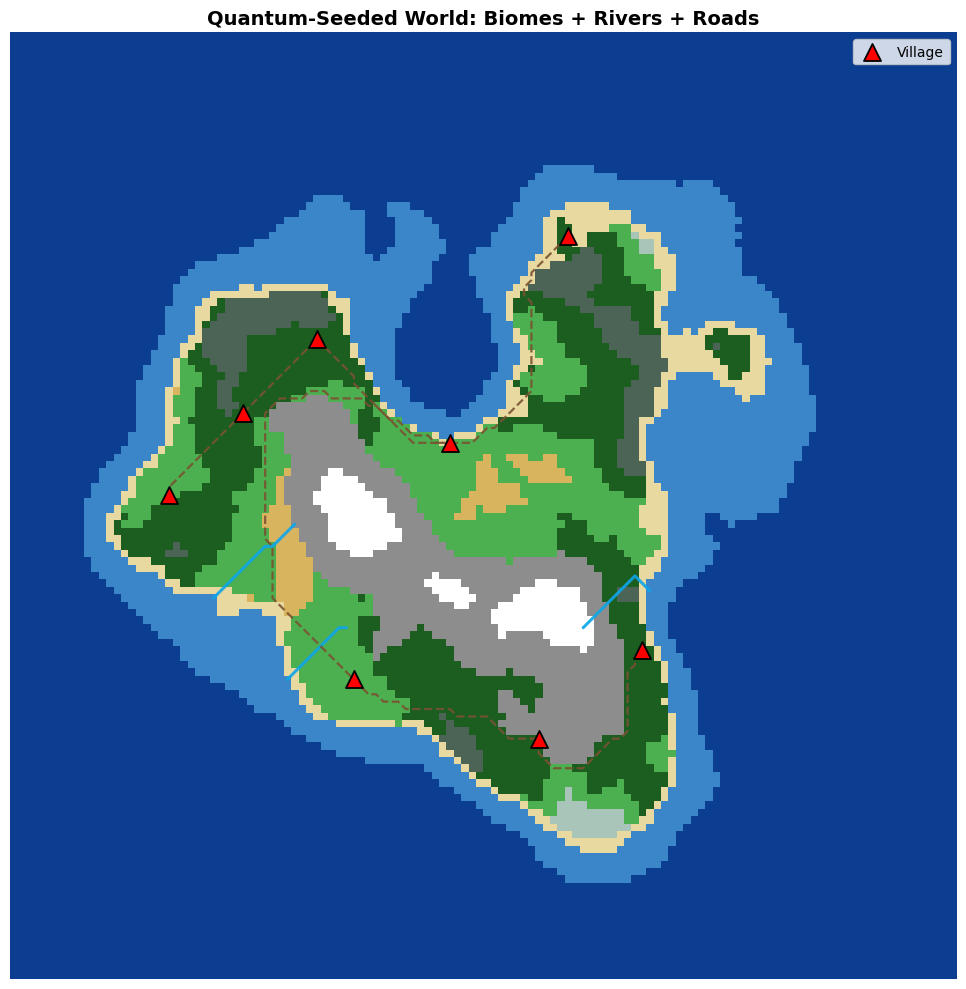


Final quantum + procedural parameter summary:
  island_falloff              : 2.1054
  terrain_scale               : 43.4139
  mountain_intensity          : 1.3357
  water_level                 : 0.3562
  forest_density              : 0.6132
  village_count               : 8
  snow_threshold_offset       : 0.015
  mountain_threshold_offset   : 0.0002
  octaves                     : 6
  persistence                 : 0.4462
  lacunarity                  : 1.8792
  moisture_scale              : 24.6227
  equator_shift               : -0.0219
  desert_moisture_t           : 0.2828
  desert_temp_t               : 0.5927
  swamp_moisture_t            : 0.6997
  swamp_height_t              : 0.5387
  tundra_temp_t               : 0.3235
  tundra_moisture_t           : 0.376
  forest_moisture_t           : 0.4969
  river_count                 : 3


In [28]:
def visualize_full_world(biome, villages, rivers, roads, params):
    rgb = biome_to_rgb(biome)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(rgb, origin='upper')

    # Rivers: bright blue lines carved across the terrain
    for river in rivers:
        rx = [p[0] for p in river]
        ry = [p[1] for p in river]
        ax.plot(rx, ry, color='#0ea5e9', linewidth=2.2, solid_capstyle='round',
                 zorder=3, alpha=0.9)

    # Roads: dashed brown lines connecting villages
    for road in roads:
        road_arr = np.array(road)
        ax.plot(road_arr[:, 0], road_arr[:, 1], color='#7a5230',
                 linewidth=1.6, linestyle='--', zorder=4, alpha=0.9)

    # Villages
    if villages:
        vx = [v[0] for v in villages]
        vy = [v[1] for v in villages]
        ax.scatter(vx, vy, marker='^', s=150, c='red', edgecolor='black',
                    linewidth=1.3, zorder=5, label='Village')
        ax.legend(loc='upper right')

    ax.set_title("Quantum-Seeded World: Biomes + Rivers + Roads",
                  fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_full_world(biome_ext, villages_ext, rivers, roads, world_params)

print("\nFinal quantum + procedural parameter summary:")
for k, v in world_params.items():
    print(f"  {k:<28s}: {v if isinstance(v, int) else round(v, 4)}")